# 03 - Data Preprocessing

Data preprocessing is one of the most important steps in a Machine Learning workflow.

Real-world data is rarely clean. It may contain:

- Missing values
- Duplicate records
- Incorrect data types
- Categorical values
- Outliers
- Different numerical scales
- Inconsistent values
- Irrelevant features
- Data leakage

Machine Learning algorithms generally expect data in a suitable numerical and structured form.

Therefore, before training a Machine Learning model, we usually need to:

1. Understand the dataset
2. Clean the data
3. Handle missing values
4. Handle duplicate and inconsistent data
5. Detect and handle outliers
6. Encode categorical variables
7. Scale numerical features when necessary
8. Split the dataset into training and testing sets
9. Build a reproducible preprocessing pipeline

---

## Learning Objective

By the end of this notebook, we should be able to take a raw dataset and transform it into a form suitable for Machine Learning.

## 1. What is Data Preprocessing?

Data preprocessing is the process of converting raw data into a clean,
consistent, and Machine Learning-ready dataset.

A typical Machine Learning workflow is:

      Raw Data

         ↓
      Data Understanding

         ↓
      Data Cleaning

         ↓
      Missing Value Handling

         ↓
      Outlier Handling

         ↓
      Categorical Encoding

         ↓
      Feature Scaling

         ↓
      Train-Test Split

         ↓
      Machine Learning Model
      

The quality of preprocessing can significantly affect the performance
of a Machine Learning model.

## Why is Data Preprocessing Important?

Suppose we have the following dataset:

| Age | Salary | City |
|---:|---:|---|
| 22 | 30000 | Kolkata |
| 25 | 40000 | Delhi |
| NaN | 50000 | Mumbai |
| 35 | 60000 | Kolkata |

A Machine Learning algorithm may not be able to directly work with:

- NaN values
- Text values such as "Kolkata"
- Different numerical scales
- Incorrect or inconsistent data

Therefore, preprocessing converts the dataset into a usable representation.

In [1]:
# NumPy is used for numerical operations
import numpy as np

# Pandas is used for data manipulation and analysis
import pandas as pd

# Matplotlib is used for visualization
import matplotlib.pyplot as plt

# Seaborn is useful for statistical visualization
import seaborn as sns

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

## 2. Creating a Sample Dataset

Before using a real-world dataset, we will create a small dataset
containing common data-quality problems.

Our dataset will contain:

- Numerical features
- Categorical features
- Missing values
- Duplicate records
- An extreme value

This allows us to practice preprocessing step by step.

In [2]:
# Create a sample dataset

data = {
    "Age": [22, 25, 28, 35, np.nan, 42, 25, 120],
    "Salary": [30000, 40000, 50000, 60000, 55000, np.nan, 40000, 70000],
    "Experience": [1, 2, 4, 8, 6, 12, 2, 5],
    "City": [
        "Kolkata",
        "Delhi",
        "Mumbai",
        "Kolkata",
        "Delhi",
        "Mumbai",
        "Delhi",
        "Kolkata"
    ],
    "Purchased": [
        "No",
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No"
    ]
}

df = pd.DataFrame(data)

df

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
4,NaN,55000.0,6,Delhi,Yes
5,42.0,NaN,12,Mumbai,Yes
6,25.0,40000.0,2,Delhi,Yes
7,120.0,70000.0,5,Kolkata,No


## 3. Understanding the Dataset

Before preprocessing data, we should understand what the dataset contains.

Important questions include:

- How many rows are present?
- How many columns are present?
- What are the column names?
- What are the data types?
- Are there missing values?
- Are there duplicate records?
- What are the statistical properties of numerical features?

Never start preprocessing blindly.

First understand the data.

In [3]:
# Display the first five rows
df.head()

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
4,NaN,55000.0,6,Delhi,Yes


In [4]:
# Display the last five rows
df.tail()

,Age,Salary,Experience,City,Purchased
3,35.0,60000.0,8,Kolkata,Yes
4,NaN,55000.0,6,Delhi,Yes
5,42.0,NaN,12,Mumbai,Yes
6,25.0,40000.0,2,Delhi,Yes
7,120.0,70000.0,5,Kolkata,No


In [5]:
# Display the number of rows and columns

df.shape

(8, 5)

In [6]:
# Display column names

df.columns

Index(['Age', 'Salary', 'Experience', 'City', 'Purchased'], dtype='str')

In [7]:
# Display information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         7 non-null      float64
 1   Salary      7 non-null      float64
 2   Experience  8 non-null      int64  
 3   City        8 non-null      str    
 4   Purchased   8 non-null      str    
dtypes: float64(2), int64(1), str(2)
memory usage: 452.0 bytes


In [8]:
# Display statistical information about numerical columns

df.describe()

,Age,Salary,Experience
count,7.000000,7.000000,8.000000
mean,42.428571,49285.714286,5.000000
std,34.894399,13671.311638,3.664502
min,22.000000,30000.000000,1.000000
25%,25.000000,40000.000000,2.000000
50%,28.000000,50000.000000,4.500000
75%,38.500000,57500.000000,6.500000
max,120.000000,70000.000000,12.000000


# 4. Types of Data

Machine Learning datasets commonly contain different types of features.

## Numerical Data

Numerical data represents quantities.

Examples:

- Age
- Salary
- Height
- Weight
- Experience

Numerical data can be:

### Discrete

Countable values.

Example:

```text
Number of children = 0, 1, 2, 3, ...
Height = 172.5 cm
Temperature = 36.7°C

```
### Categorical Data

City = Kolkata, Delhi, Mumbai

Gender = Male, Female

Purchased = Yes, No

In [9]:
# Check the data type of every column

df.dtypes

Age           float64
Salary        float64
Experience      int64
City              str
Purchased         str
dtype: object

# 5. Missing Values

Missing data occurs when a value is not available for a particular observation.

For example:

| Age | Salary |
|---:|---:|
| 22 | 30000 |
| 25 | 40000 |
| NaN | 50000 |

`NaN` means the value is missing.

Missing values can occur because of:

- Data entry errors
- Sensor failures
- Missing responses
- Database problems
- Data collection issues

Machine Learning models generally cannot directly handle missing values
unless the algorithm specifically supports them.

Therefore, we need to identify and handle them.

In [10]:
# Check whether each value is missing

df.isnull()

,Age,Salary,Experience,City,Purchased
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,True,False,False,False,False
5,False,True,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False


In [11]:
# Count missing values in every column

df.isnull().sum()

Age           1
Salary        1
Experience    0
City          0
Purchased     0
dtype: int64

In [12]:
# Calculate the percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Age           12.5
Salary        12.5
Experience     0.0
City           0.0
Purchased      0.0
dtype: float64

## Removing Rows with Missing Values

One simple approach is to remove rows containing missing values.

Pandas provides:

```python
dropna()

In [13]:

## Cell 21 — Code

# Create a copy so that the original dataset remains unchanged

df_dropna = df.copy()

# Remove rows containing at least one missing value

df_dropna = df_dropna.dropna()

df_dropna

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
6,25.0,40000.0,2,Delhi,Yes
7,120.0,70000.0,5,Kolkata,No


# 6. Mean Imputation

Instead of deleting a missing numerical value, we can replace it
with the mean of that feature.

The arithmetic mean is:

$$
\bar{x} = \frac{x_1 + x_2 + x_3 + \cdots + x_n}{n}
$$

For example:

Data:

```text
10, 20, 30
```
$$
\bar{x} = \frac{10 + 20 + 30 }{3} = 20
$$


In [14]:

## Cell 23 — Code

# Create a copy of the dataset

df_mean = df.copy()

# Calculate the mean age
mean_age = df_mean["Age"].mean()

# Replace missing Age values with the mean
df_mean["Age"] = df_mean["Age"].fillna(mean_age)

df_mean

,Age,Salary,Experience,City,Purchased
0,22.000000,30000.0,1,Kolkata,No
1,25.000000,40000.0,2,Delhi,Yes
2,28.000000,50000.0,4,Mumbai,No
3,35.000000,60000.0,8,Kolkata,Yes
4,42.428571,55000.0,6,Delhi,Yes
5,42.000000,NaN,12,Mumbai,Yes
6,25.000000,40000.0,2,Delhi,Yes
7,120.000000,70000.0,5,Kolkata,No


# 7. Median Imputation

The median is the middle value after sorting the data.

Example:

```text
10, 20, 30, 40, 50
If there is an even number of observations:
```
$$
Median = \frac{ 20 + 30 }{2} = 25
$$


In [15]:
# Create a copy

df_median = df.copy()

# Calculate the median age
median_age = df_median["Age"].median()

# Replace missing Age values
df_median["Age"] = df_median["Age"].fillna(median_age)

df_median

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
4,28.0,55000.0,6,Delhi,Yes
5,42.0,NaN,12,Mumbai,Yes
6,25.0,40000.0,2,Delhi,Yes
7,120.0,70000.0,5,Kolkata,No


# 8. Mode Imputation

The mode is the most frequently occurring value.

Example:

```text
Kolkata
Delhi
Kolkata
Mumbai
Kolkata

In [16]:
# Create a copy

df_mode = df.copy()

# Calculate the mode of City
city_mode = df_mode["City"].mode()[0]

# Replace missing City values
df_mode["City"] = df_mode["City"].fillna(city_mode)

df_mode

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
4,NaN,55000.0,6,Delhi,Yes
5,42.0,NaN,12,Mumbai,Yes
6,25.0,40000.0,2,Delhi,Yes
7,120.0,70000.0,5,Kolkata,No


# 9. Duplicate Data

Duplicate rows can occur when:

- Data is collected multiple times
- Records are accidentally inserted twice
- Multiple data sources are merged

Duplicate data can distort analysis and Machine Learning models.

Pandas provides:

```python
duplicated()

In [17]:
# Identify duplicate rows

df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
dtype: bool

In [18]:
# Count duplicate rows

df.duplicated().sum()

np.int64(1)

In [19]:
# Remove duplicate rows

df_no_duplicates = df.drop_duplicates()

df_no_duplicates

,Age,Salary,Experience,City,Purchased
0,22.0,30000.0,1,Kolkata,No
1,25.0,40000.0,2,Delhi,Yes
2,28.0,50000.0,4,Mumbai,No
3,35.0,60000.0,8,Kolkata,Yes
4,NaN,55000.0,6,Delhi,Yes
5,42.0,NaN,12,Mumbai,Yes
7,120.0,70000.0,5,Kolkata,No


# 10. Inconsistent Data

Real-world datasets can contain inconsistent representations.

For example:

```text
Kolkata
kolkata
KOLKATA

In [20]:
# Example of standardizing text

df_clean = df.copy()

df_clean["City"] = df_clean["City"].str.lower().str.strip()

df_clean["City"]

0    kolkata
1      delhi
2     mumbai
3    kolkata
4      delhi
5     mumbai
6      delhi
7    kolkata
Name: City, dtype: str

# 11. Outliers

An outlier is an observation that is unusually far from the
other observations.

Example:

```text
20
22
24
25
23
21
150

## Detecting Outliers using IQR

IQR stands for Interquartile Range.

First we calculate:

- Q1 = 25th percentile
- Q3 = 75th percentile

Then:

$$
IQR = Q3 - Q1
$$

The common lower and upper boundaries are:

$$
Lower\ Bound = Q1 - 1.5(IQR)
$$

$$
Upper\ Bound = Q3 + 1.5(IQR)
$$

Any value outside these boundaries is considered a potential outlier.

In [21]:
# Select the Age column

age = df["Age"].dropna()

# Calculate Q1 and Q3
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 25.0
Q3: 38.5
IQR: 13.5
Lower Bound: 4.75
Upper Bound: 58.75


In [22]:
# Identify potential outliers

outliers = df[
    (df["Age"] < lower_bound) |
    (df["Age"] > upper_bound)
]

outliers

,Age,Salary,Experience,City,Purchased
7,120.0,70000.0,5,Kolkata,No


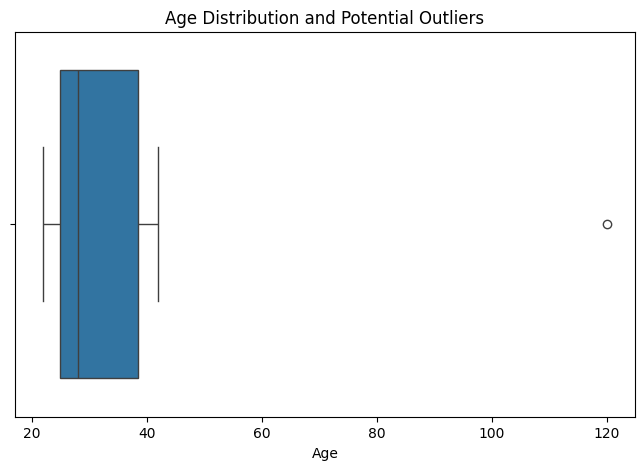

In [23]:
# Create a box plot for Age

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Age Distribution and Potential Outliers")
plt.xlabel("Age")

plt.show()

# 12. Categorical Encoding

Most Machine Learning algorithms operate on numerical representations.

Suppose we have:

| City |
|---|
| Kolkata |
| Delhi |
| Mumbai |

A model cannot directly perform mathematical operations on these strings.

Therefore, categorical variables must often be converted into numerical
representations.

Common encoding methods:

1. Label Encoding
2. Ordinal Encoding
3. One-Hot Encoding

## Label Encoding

Label Encoding assigns an integer to each category.

Example:

```text
No  → 0
Yes → 1

In [24]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder
label_encoder = LabelEncoder()

# Encode Purchased
purchased_encoded = label_encoder.fit_transform(df["Purchased"])

purchased_encoded

array([0, 1, 0, 1, 1, 1, 1, 0])

In [25]:
# Display the mapping

for category, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(category, "->", encoded_value)

No -> 0
Yes -> 1


# 13. One-Hot Encoding

One-Hot Encoding creates a separate binary column for each category.

Example:

| City |
|---|
| Kolkata |
| Delhi |
| Mumbai |

becomes:

| City_Delhi | City_Kolkata | City_Mumbai |
|---:|---:|---:|
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 0 | 0 | 1 |

This is generally appropriate for nominal categorical variables where
there is no natural ordering.

In [26]:
# Perform one-hot encoding

df_encoded = pd.get_dummies(
    df,
    columns=["City"],
    dtype=int
)

df_encoded

,Age,Salary,Experience,Purchased,City_Delhi,City_Kolkata,City_Mumbai
0,22.0,30000.0,1,No,0,1,0
1,25.0,40000.0,2,Yes,1,0,0
2,28.0,50000.0,4,No,0,0,1
3,35.0,60000.0,8,Yes,0,1,0
4,NaN,55000.0,6,Yes,1,0,0
5,42.0,NaN,12,Yes,0,0,1
6,25.0,40000.0,2,Yes,1,0,0
7,120.0,70000.0,5,No,0,1,0


# 14. Feature Scaling

Suppose a dataset contains:

```text
Age        → 18 to 60
Salary     → 20,000 to 200,000
Experience → 0 to 20
```
These features have very different numerical scales.

Some Machine Learning algorithms are sensitive to feature magnitude.

Examples include:

    K-Nearest Neighbors
    K-Means
    Support Vector Machines
    Logistic Regression
    Neural Networks

Tree-based algorithms such as Decision Trees and Random Forests
generally do not require feature scaling.

Two important scaling techniques are:

    1.Standardization
    2.Normalization


---

# 15. Standardization

Standardization transforms a feature so that it approximately has:

- Mean = 0
- Standard deviation = 1

The formula is:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

- $x$ = original value
- $\mu$ = mean
- $\sigma$ = standard deviation
- $z$ = standardized value

Example:

Suppose:

$$
x = 70
$$

$$
\mu = 50
$$

$$
\sigma = 10
$$

Then:

$$
z = \frac{70-50}{10}
$$

$$
z = 2
$$

So the value is two standard deviations above the mean.

In [27]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
standard_scaler = StandardScaler()

# Select numerical columns
numerical_features = ["Age", "Salary", "Experience"]

# Create a copy
df_scaled = df.copy()

# Fill missing values temporarily using median
df_scaled[numerical_features] = df_scaled[numerical_features].fillna(
    df_scaled[numerical_features].median()
)

# Standardize numerical features
df_scaled[numerical_features] = standard_scaler.fit_transform(
    df_scaled[numerical_features]
)

df_scaled

,Age,Salary,Experience,City,Purchased
0,-0.608782,-1.636117,-1.16692,Kolkata,No
1,-0.510723,-0.791670,-0.87519,Delhi,Yes
2,-0.412664,0.052778,-0.29173,Mumbai,No
3,-0.183860,0.897226,0.87519,Kolkata,Yes
4,-0.412664,0.475002,0.29173,Delhi,Yes
5,0.044944,0.052778,2.04211,Mumbai,Yes
6,-0.510723,-0.791670,-0.87519,Delhi,Yes
7,2.594475,1.741673,0.00000,Kolkata,No


# 16. Normalization

A common normalization technique is Min-Max Scaling.

The formula is:

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

This transforms values approximately into the range:

$$
0 \leq x' \leq 1
$$

Example:

Suppose:

$$
x=50
$$

$$
x_{min}=10
$$

$$
x_{max}=90
$$

Then:

$$
x'=\frac{50-10}{90-10}
$$

$$
x'=0.5
$$

In [28]:
from sklearn.preprocessing import MinMaxScaler

# Create the Min-Max scaler
min_max_scaler = MinMaxScaler()

# Create a copy
df_normalized = df.copy()

# Fill missing numerical values with their median
df_normalized[numerical_features] = df_normalized[
    numerical_features
].fillna(df_normalized[numerical_features].median())

# Apply Min-Max scaling
df_normalized[numerical_features] = min_max_scaler.fit_transform(
    df_normalized[numerical_features]
)

df_normalized

,Age,Salary,Experience,City,Purchased
0,0.000000,0.000,0.000000,Kolkata,No
1,0.030612,0.250,0.090909,Delhi,Yes
2,0.061224,0.500,0.272727,Mumbai,No
3,0.132653,0.750,0.636364,Kolkata,Yes
4,0.061224,0.625,0.454545,Delhi,Yes
5,0.204082,0.500,1.000000,Mumbai,Yes
6,0.030612,0.250,0.090909,Delhi,Yes
7,1.000000,1.000,0.363636,Kolkata,No


# 17. Train-Test Split

Before training a Machine Learning model, we normally divide the dataset
into separate training and testing sets.

### Training Set

Used to train the Machine Learning model.

### Testing Set

Used to evaluate how well the model performs on unseen data.

A common split is:

```text
80% → Training
20% → Testing


---

# 18. Data Leakage

Data leakage occurs when information from outside the training data
incorrectly influences the training process.

For example, suppose we calculate the mean of a feature using the
entire dataset before splitting:

```text
Entire Dataset
      ↓
Calculate Mean
      ↓
Train-Test Split

A better approach is:
      Dataset
         ↓
   Train-Test Split
         ↓
  Training Data → Calculate Mean
         ↓
  Apply same mean → Test Data

In [29]:
# 25. Correct Train-Test Split
from sklearn.model_selection import train_test_split

# Create a simple dataset for demonstration

X = df[["Age", "Salary", "Experience"]]
y = df["Purchased"]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (6, 3)
Testing features: (2, 3)
Training target: (6,)
Testing target: (2,)


# 19. Professional Preprocessing with Scikit-Learn

In real Machine Learning projects, preprocessing should be reproducible.

Our dataset contains:

### Numerical features

- Age
- Salary
- Experience

### Categorical features

- City

We want to:

1. Fill missing numerical values
2. Standardize numerical features
3. Fill missing categorical values
4. One-hot encode categorical features

Scikit-Learn provides:

- `SimpleImputer`
- `StandardScaler`
- `OneHotEncoder`
- `ColumnTransformer`
- `Pipeline`

These tools allow us to construct a reliable preprocessing workflow.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numerical and categorical columns

numerical_features = [
    "Age",
    "Salary",
    "Experience"
]

categorical_features = [
    "City"
]

# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

## Fit vs Transform

This distinction is extremely important.

### fit()

The preprocessing object learns information from the data.

For example, `StandardScaler` learns:

- Mean
- Standard deviation

`SimpleImputer` learns:

- Median
- Mean
- Mode

depending on the selected strategy.

---

### transform()

The learned preprocessing rules are applied to data.

---

### fit_transform()

Performs both operations together.

For training data:

```python
fit_transform()

For testing data:
transform()

In [31]:
# Separate features and target

X = df[
    numerical_features + categorical_features
]

y = df["Purchased"]

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit preprocessing only on training data

X_train_processed = preprocessor.fit_transform(X_train)

# Apply learned preprocessing to test data

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (6, 6)
Processed testing shape: (2, 6)


# 20. Complete Data Preprocessing Workflow

A practical preprocessing workflow can be summarized as:

```text
                 Raw Dataset
                      │
                      ▼
              Understand Dataset
                      │
                      ▼
             Separate X and y
                      │
                      ▼
              Train-Test Split
                 /          \
                /            \
               ▼              ▼
           X_train          X_test
               │              │
               ▼              │
       Learn preprocessing    │
               │              │
       ┌───────┴────────┐     │
       ▼                ▼     │
 Numerical          Categorical
       │                │
       ▼                ▼
 Imputation         Imputation
       │                │
       ▼                ▼
 Scaling            Encoding
       │                │
       └───────┬────────┘
               ▼
        Processed X_train
               │
               │
       Same transformation
               │
               ▼
        Processed X_test
               │
               ▼
         Machine Learning
             Model


---
# 21. Mini Project: Prepare a Dataset for Machine Learning

We will now create a complete preprocessing pipeline.

Our objective:

- Handle missing numerical values
- Scale numerical features
- Handle missing categorical values
- One-hot encode categorical features
- Split training and testing data
- Prevent data leakage

This structure can later be connected directly to a Machine Learning model.

In [32]:
# Complete preprocessing pipeline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --------------------------------------------------
# Step 1: Define features and target
# --------------------------------------------------

X = df.drop(columns=["Purchased"])
y = df["Purchased"]

# --------------------------------------------------
# Step 2: Identify feature types
# --------------------------------------------------

numerical_features = [
    "Age",
    "Salary",
    "Experience"
]

categorical_features = [
    "City"
]

# --------------------------------------------------
# Step 3: Split data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Step 4: Numerical preprocessing
# --------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# --------------------------------------------------
# Step 5: Categorical preprocessing
# --------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# --------------------------------------------------
# Step 6: Combine preprocessing
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# --------------------------------------------------
# Step 7: Fit on training data
# --------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

# --------------------------------------------------
# Step 8: Transform test data
# --------------------------------------------------

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (6, 4)
Processed training shape: (6, 6)
Original testing shape: (2, 4)
Processed testing shape: (2, 6)


# 22. Important Concepts

## Missing Values

Common strategies:

- Remove rows
- Remove columns
- Mean imputation
- Median imputation
- Mode imputation

---

## Outliers

Common detection methods:

- IQR
- Z-score
- Visualization

Do not automatically remove every outlier.

---

## Encoding

### Label Encoding

Useful for binary or ordered categories in appropriate situations.

### One-Hot Encoding

Useful for nominal categories.

---

## Scaling

### Standardization

$$
z = \frac{x-\mu}{\sigma}
$$

Usually produces approximately:

$$
\mu = 0,\quad \sigma = 1
$$

### Min-Max Normalization

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

Usually produces values between:

$$
0 \leq x' \leq 1
$$

---

## Train-Test Split

Training data is used to learn.

Testing data is used to evaluate.

---

## Data Leakage

Never allow information from the test set to influence training or
preprocessing parameter estimation.

---

## Pipeline

A Pipeline combines preprocessing operations into a reproducible workflow.

# 23. Summary

In this notebook we learned the fundamentals of Data Preprocessing.

### We learned:

- What data preprocessing is
- Why preprocessing is necessary
- Numerical and categorical data
- Dataset inspection
- Missing-value detection
- Missing-value imputation
- Duplicate removal
- Data consistency
- Outlier detection
- IQR
- Categorical encoding
- Label Encoding
- One-Hot Encoding
- Feature scaling
- Standardization
- Min-Max Normalization
- Train-Test Split
- Data Leakage
- `SimpleImputer`
- `StandardScaler`
- `OneHotEncoder`
- `ColumnTransformer`
- `Pipeline`

---

## Core Machine Learning Principle

A good Machine Learning workflow is not simply:

```text
Dataset → Model

It is:

    Raw Data
    ↓
    Understand
    ↓
    Clean
    ↓
    Preprocess
    ↓
    Split
    ↓
    Train
    ↓
    Evaluate
    ↓
    Improve